# Packages

In [140]:
%matplotlib widget

In [141]:
try:
    import cupy as xp
except ImportError:
    import numpy as xp

In [142]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from cupyx.scipy.ndimage import shift as shiftcp

In [143]:
from libertem_holo.base.io import Results, InputData
from libertem_holo.base.reconstr import reconstruct_frame, reconstruct_bf, phase_offset_correction
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import ImageCorrelator
from libertem_holo.base.filters import clipped
from libertem_holo.base.unwrap import phase_unwrap

# Load hologram stacks

Data is loaded from dm3 or dm4 files directly into a 'data' object which contains the stack as well as metadata information such as the pixel size in meters, the total exposure time in seconds and the GMS tags.

In [144]:
# Reference stack
path = "/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/reconstr/stack_ref_plus.dm4"
data_ref = InputData.load_from_dm(path)

# Object stack
path = "/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/reconstr/stack_obj_plus.dm4"
data_obj = InputData.load_from_dm(path)

In [145]:
data_obj.pixelsize, data_obj.exposure_time, data_obj.shape

(1.4522670209407806e-10, np.float64(60.0), (30, 3838, 3710))

Text(0, 0.5, 'nm')

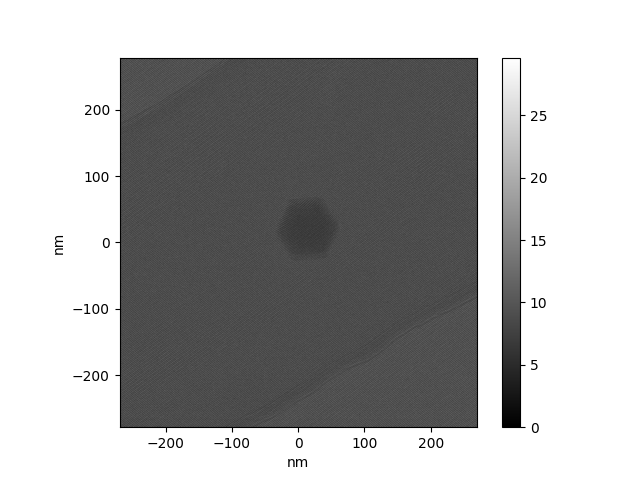

In [146]:
# Show one frame of the stack

frame = data_obj.data[0]
extent=(
    -data_obj.pixelsize*frame.shape[1]/2*1e9, data_obj.pixelsize*frame.shape[1]/2*1e9,
    -data_obj.pixelsize*frame.shape[0]/2*1e9, data_obj.pixelsize*frame.shape[0]/2*1e9,
)
plt.figure()
im = plt.imshow(
    frame, vmin=np.min(clipped(frame)), vmax=np.max(clipped(frame)),
    extent=extent, cmap='gray',
)
plt.colorbar()
plt.xlabel('nm')
plt.ylabel('nm')

# Hologram reconstruction parameters

The hologram reconstruction parameters are:

    - sideband position
    
    - sideband size
    
    - output shape
    
    - line filter for Fresnel fringes (length and width)
    
    - Butterworth filter order
    
The parameters are stored in the 'HoloParams' object. A convenient function 'from_hologram' calculates all parameters automatically with default values, but every parameter is editable. 

In [147]:
# One frame is passed as argument for the parameters determination, for example the first frame of the reference stack.

holoparams = HoloParams.from_hologram(data_ref.data[0], xp=xp)

In [148]:
holoparams.sb_size, holoparams.sb_position, holoparams.out_shape

(121.65627809529602, (3639.0, 3570.0), (959, 927))

In [149]:
# if necessary, we can force a sideband size, or output shape in the holoparams
# if the output shape does not respect the aspect ratio of the original hologram, 
# a warning is raised to warn the user that the pixel size will no longer be valid for 
# both x and y dimensions, continue at your own risk

holoparams = HoloParams.from_hologram(data_ref.data[0], xp=xp, sb_size=200, out_shape=(512, 512))

In [150]:
holoparams.sb_size, holoparams.sb_position, holoparams.out_shape

(200, (3639.0, 3570.0), (512, 512))

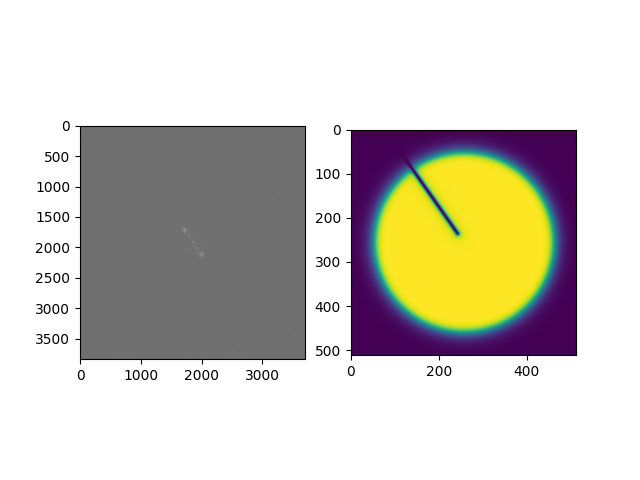

In [151]:
# we can visualise the aperture created to filter the FFT

fig, ax = plt.subplots(ncols=2)#, sharex=True, sharey=True)
aperture = xp.fft.fftshift(holoparams.aperture).get()
fft = xp.fft.fftshift(xp.fft.fft2(xp.asarray(data_obj.data[0]))).get()
#fft = xp.roll(fft, np.array(holoparams.sb_position_int).astype(np.int64), axis=(0, 1)).get()
#fft = fft[holoparams.slice_fft]

ax[0].imshow(np.log1p(np.abs(fft)), cmap='gray')
ax[1].imshow(aperture)

# Reconstruction of one frame

In [152]:
# before reconstructing the whole stack, it can be useful to check the reconstruction parameters
# by reconstructing one single frame and plotting the amplitude and phase of the complex wave.

# First the object wave is reconstructed
wave_obj = reconstruct_frame(
    data_obj.data[0], sb_pos=holoparams.sb_position, aperture=holoparams.aperture,
    slice_fft=holoparams.slice_fft, xp=xp
)

# Then the reference wave...
wave_ref = reconstruct_frame(
    data_ref.data[0], sb_pos=holoparams.sb_position, aperture=holoparams.aperture,
    slice_fft=holoparams.slice_fft, xp=xp
)

# ... and the reference wave is removed from the object wave to reduce distorsions
wave = wave_obj / wave_ref

If you are using a GPU and the cupy library instead of numpy, the final wave must be transferred to CPU before plotting

In [153]:
wave = wave.get()

The amplitude and phase images can then be extracted and plotted

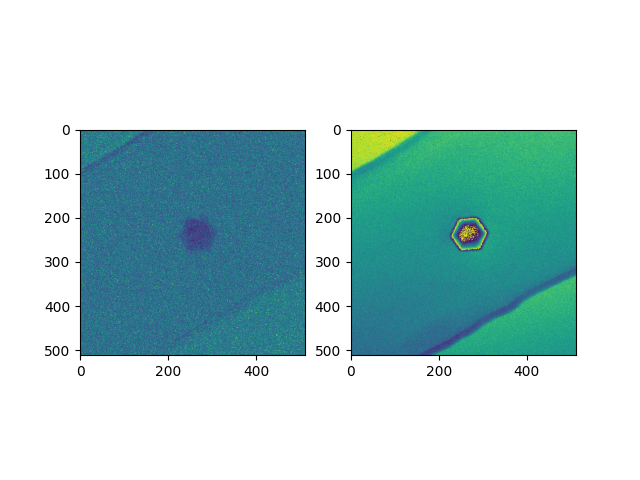

In [154]:
amp = np.abs(wave)
phase = np.angle(wave)

fig, ax = plt.subplots(ncols=2)
ax[0].imshow(amp, vmin=np.min(clipped(amp)), vmax=np.max(clipped(amp)))
ax[1].imshow(phase)

The bright field (centerband filtering) of the hologram can also be reconstructed. The same 'holoparams' can be used as well.

In [155]:
bf = reconstruct_bf(data_obj.data[0], aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)

In [156]:
# if using cupy
bf = bf.get()

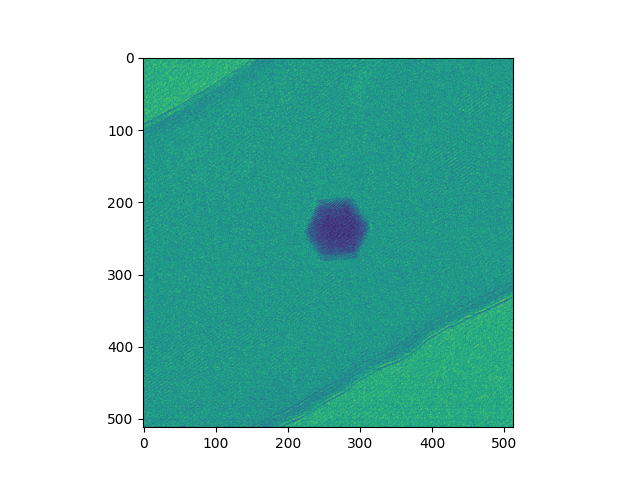

In [157]:
plt.figure()
plt.imshow(bf)

# Reconstruction stack

Now that we are satisfied with our reconstruction parameters, we can reconstruct a stack.

temporary function, needs to import it from convenience ? or reconstr module

In [158]:
def reconstruct_stack(stack, stack_ref=None, holoparams=None, xp=xp):
    sig_shape = stack.data[0].shape
    out_shape = (sig_shape[0]//2, sig_shape[1]//2)
    if holoparams is None:
        holoparams = HoloParams.from_hologram(
            stack.data[0], out_shape=out_shape, xp=xp,
            line_filter_width=2, line_filter_length=0.9, central_band_mask_radius=100,
        )
    px_size = stack.pixelsize * holoparams.scale_factor
    correlator = ImageCorrelator(hanning=True, normalization='phase', binning=2, upsample_factor=10, xp=xp)
    waves_aligned = []
    bfs_aligned = []
    for i in tqdm(range(len(stack.data))):
        obj = stack.data[i]

        wave_obj = reconstruct_frame(
            frame=obj, sb_pos=holoparams.sb_position,
            aperture=holoparams.aperture, slice_fft=holoparams.slice_fft,
            xp=xp,
        )
        if i == 0:
            bf_obj_0 = reconstruct_bf(frame=obj, aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)
            f1 = correlator.prepare_input(bf_obj_0)

        bf_obj = reconstruct_bf(frame=obj, aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)
        f2 = correlator.prepare_input(bf_obj)

        corr_res = correlator.correlate(ref_image=f1, moving_image=f2)
        shifts = corr_res.shift

        if wave_obj.device == 'cpu':
            shifts = tuple(float(x) for x in corr_res.shift)
            wave_shifted = shift(wave_obj, shifts)
            bf_shifted = shift(bf_obj, shifts)
        else:
            wave_shifted = shiftcp(wave_obj, shifts)
            bf_shifted = shiftcp(bf_obj, shifts)

        waves_aligned.append(wave_shifted)
        bfs_aligned.append(bf_shifted)

    waves_aligned = np.stack(waves_aligned)
    bfs_aligned = np.stack(bfs_aligned)

    wave_avg, _, _ = phase_offset_correction(waves_aligned, xp=xp)
    bf_avg = np.mean(np.abs(bfs_aligned), axis=0)


    if stack_ref is None:
        wave_ref = np.ones_like(wave_avg)
    else:
        if holoparams is None:
            holoparams = HoloParams.from_hologram(
                stack_ref.data[0], out_shape=out_shape, xp=xp, line_filter_width=5, line_filter_length=0.9, central_band_mask_radius=100,
            )
        waves_ref = []

        for i in tqdm(range(len(stack_ref.data))):
            ref = stack_ref.data[i]
            wave_ref = reconstruct_frame(
                frame=ref, sb_pos=holoparams.sb_position, 
                aperture=holoparams.aperture, slice_fft=holoparams.slice_fft,
                xp=xp,
            )
            waves_ref.append(wave_ref)

        waves_ref = np.stack(waves_ref)
        wave_ref, _, _ = phase_offset_correction(waves_ref, xp=xp)

    wave = wave_avg / wave_ref
    return wave.get(), bf_avg.get(), holoparams

In [159]:
wave, bf, holoparams = reconstruct_stack(stack=data_obj, stack_ref=data_ref, holoparams=None)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [160]:
phase = phase_unwrap(np.angle(wave))

In [161]:
res = Results(complex_wave=wave, unwrapped_phase=phase, brightfield=bf)

`res` contains `complex_wave`, `unwrapped_phase`  and `brightfield`. Metadata can also be added.

In [162]:
res.metadata = {'temperature': 300, 'T unit': 'K'}

In [163]:
res.metadata

{'temperature': 300, 'T unit': 'K'}

or add metadata from input, which will include the effective pixel size after hologram reconstruction

In [164]:
res.metadata_from_input(input_data=data_obj, params=holoparams)

In [165]:
res.metadata

{'temperature': 300,
 'T unit': 'K',
 'stack_shape': [30, 3838, 3710],
 'exposure_time': 60.0,
 'effective_pixelsize': 2.9045340418815613e-10,
 'acquisition_timestamp': '2025-12-02T14:07:07.149649+00:00'}

In [166]:
extent = (
    0, res.unwrapped_phase.shape[1] * res.metadata['effective_pixelsize']*1e9,
    0, res.unwrapped_phase.shape[0] * res.metadata['effective_pixelsize']*1e9
)

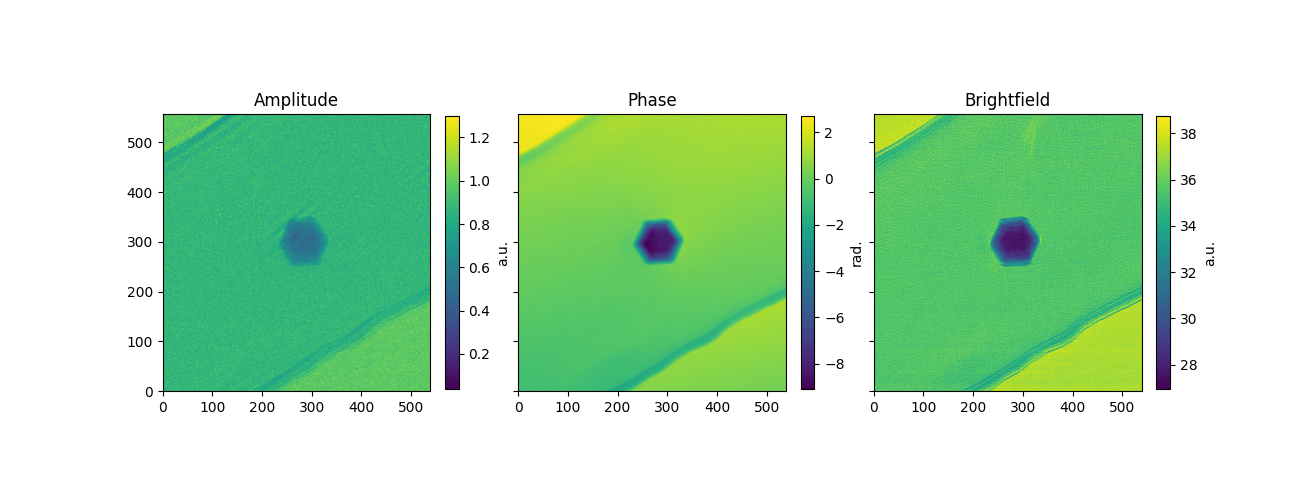

In [167]:
fig, ax = plt.subplots(ncols=3, sharex=True, sharey=True, figsize=(13, 5))
idx = 50
roi=np.s_[idx:-idx, idx:-idx]
amp = np.abs(res.complex_wave)
phase = res.unwrapped_phase
bf = res.brightfield
im = ax[0].imshow(amp[roi], extent=extent, vmin=np.min(clipped(amp)), vmax=np.max(clipped(amp)))
ax[0].set_title('Amplitude')
plt.colorbar(im, fraction=0.046, label='a.u.')
im = ax[1].imshow(phase[roi], extent=extent)
ax[1].set_title('Phase')
plt.colorbar(im, fraction=0.046, label='rad.')
im = ax[2].imshow(bf[roi], extent=extent)
ax[2].set_title('Brightfield')
plt.colorbar(im, fraction=0.046, label='a.u.')

# Phase ramp

Sometimes if the sideband is not perfectly centered or there are some distorsions from the microscope, a phase ramp can be observed across the phase image.

A function to remove this ramp can be used:

In [168]:
from libertem_holo.base.utils import remove_phase_ramp

A region-of-interest where no phase gradient is expected can be added as input.

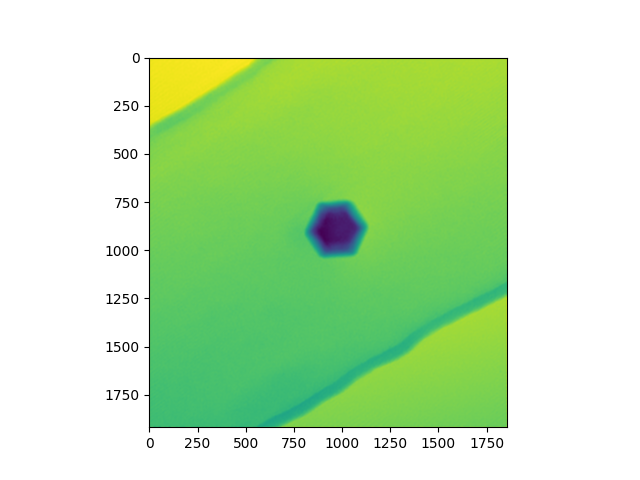

In [169]:
plt.figure()
plt.imshow(res.unwrapped_phase)

In [170]:
phase_t, _, _ = remove_phase_ramp(res.unwrapped_phase, roi=np.s_[250:700, 1000:1500], method = 'gradient')

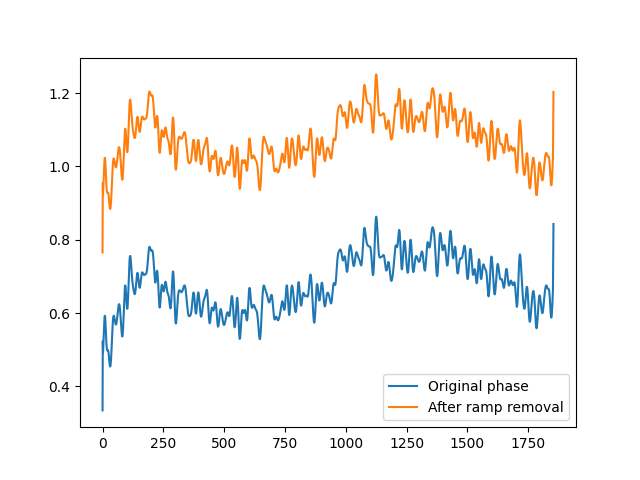

In [171]:
plt.figure()
plt.plot(res.unwrapped_phase[500, ...], label='Original phase')
plt.plot(phase_t[500, ...], label='After ramp removal')
plt.legend()

The `res` object can be modified to accept the new phase easily.

In [172]:
res.unwrapped_phase = phase_t

Finally, the dataset can be saved as a .npz file.

In [173]:
res.save("plus.npz")

# Phase unwrapping

Phase unwrapping can introduce a lot of artefacts due to low signal-to-noise ratio, hard edges, large phase gradient...  The basic `phase_unwrap` function is directly coming from the skimage package and can be used on a complex wave or a wrapped phase. Additionnal algorithms are also implement in the `unwrap` module based on quality guided unwrapping and least-square fitting unwrapping. However, the latter still introduces artefacts and should not be used for quantitative analysis of off-axis electron holography.

Quality based unwrapping:

In [174]:
from libertem_holo.base.unwrap import quality_unwrap, derivative_variance

In [175]:
phase_wrapped = np.angle(res.complex_wave)
quality_map = derivative_variance(phase_wrapped)
phase_unwrapped = quality_unwrap(phase_wrapped, quality=quality_map)

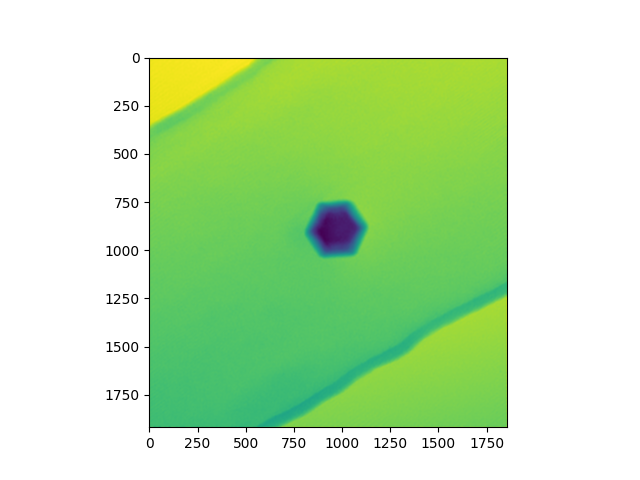

In [176]:
plt.figure()
plt.imshow(phase_unwrapped)

Least-square unwrapping:
COMING SOON

In [177]:
#from libertem_holo.base.unwrap import ls_unwrap